<a href="https://colab.research.google.com/github/ai1108/customer-transaction-prediction-lr-vs-mlp/blob/main/transaction_prediction_lr_vs_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 環境設定與套件載入**


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)


# **2. 資料讀取與基本檢視**


In [ ]:

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample_submission shape:", sample_sub.shape)

train.head()


train shape: (200000, 202)
test shape: (200000, 201)
sample_submission shape: (200000, 2)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104



## 3. 欄位說明

- `ID_code`：每筆資料的識別碼，不拿來訓練
- `target`：標籤，1 表示有交易，0 表示沒有交易
- `var_0 ~ var_199`：數值特徵，共 200 個


In [ ]:

feature_cols = [c for c in train.columns if c not in ["ID_code", "target"]]

X = train[feature_cols]
y = train["target"]
X_test_raw = test[feature_cols]

print("特徵數量：", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)


特徵數量： 200
X shape: (200000, 200)
y shape: (200000,)


## 4. 切分 train / validation

In [ ]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)


X_train: (160000, 200)
X_val: (40000, 200)



## 5. StandardScaler（MLP 很重要）

這題雖然都是數值特徵，但對 MLP 而言，做 scaling 仍然很重要。  
我們只用 training set `fit`，再把同一個 scaler 套到 validation 和 test。


In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_raw)

print(type(X_train_scaled), X_train_scaled.shape)


<class 'numpy.ndarray'> (160000, 200)


## 6. Baseline 1：Logistic Regression

In [ ]:

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

val_pred_lr = lr.predict_proba(X_val_scaled)[:, 1]
val_auc_lr = roc_auc_score(y_val, val_pred_lr)

print(f"Logistic Regression validation AUC: {val_auc_lr:.6f}")


Logistic Regression validation AUC: 0.859862


## 7. Baseline 2：MLP（含 Dropout + L2）

In [ ]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1.2e-3)
    ),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1.2e-3)
    ),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,049 (133.00 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2.5e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - auc: 0.8806 - loss: 0.2330 - val_auc: 0.8574 - val_loss: 0.2506
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8811 - loss: 0.2322 - val_auc: 0.8574 - val_loss: 0.2504
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - auc: 0.8814 - loss: 0.2319 - val_auc: 0.8574 - val_loss: 0.2503
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.8822 - loss: 0.2312 - val_auc: 0.8575 - val_loss: 0.2501
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8821 - loss: 0.2310 - val_auc: 0.8574 - val_loss: 0.2500
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.8834 - loss: 0.2302 - val_auc: 0.8574 - val_loss: 0.2500
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.8839 - loss: 0.2293 - val_auc: 0.8573 - val_loss: 0.2499


## 8. 畫出訓練曲線

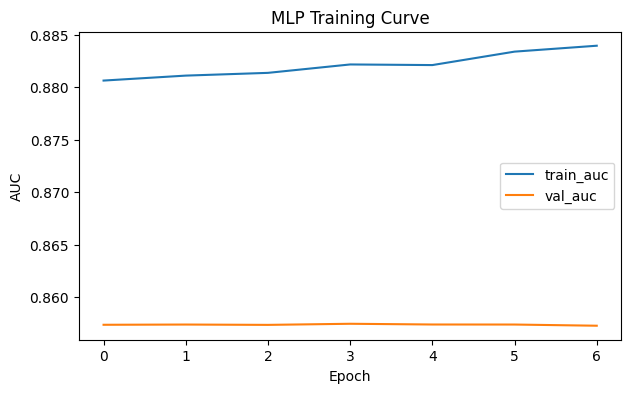

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("MLP Training Curve")
plt.legend()
plt.show()


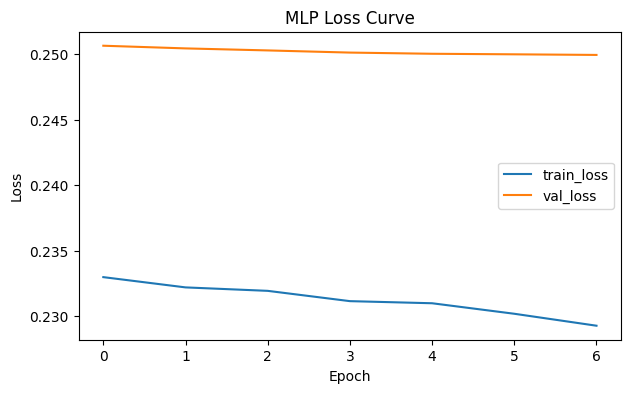

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss Curve")
plt.legend()
plt.show()


## 9. 驗證集表現

In [ ]:

val_pred_mlp = model.predict(X_val_scaled, verbose=0).flatten()
val_auc_mlp = roc_auc_score(y_val, val_pred_mlp)

print(f"MLP validation AUC: {val_auc_mlp:.6f}")

print("\n模型比較")
print(f"Logistic Regression AUC: {val_auc_lr:.6f}")
print(f"MLP AUC:                {val_auc_mlp:.6f}")


MLP validation AUC: 0.857834

模型比較
Logistic Regression AUC: 0.859862
MLP AUC:                0.857834



## 10. 產生 submission.csv

Kaggle 這題需要兩欄：

- `ID_code`
- `target`

其中 `target` 要填的是**預測機率**，不是 0/1 類別。


In [ ]:

test_pred = model.predict(X_test_scaled, verbose=0).flatten()

submission = sample_sub.copy()
submission["target"] = test_pred

submission.head()


,ID_code,target
0,test_0,0.251719
1,test_1,0.253593
2,test_2,0.039297
3,test_3,0.154187
4,test_4,0.046910


In [ ]:

submission.to_csv("submission0226.csv", index=False)
print("submission.csv 已建立完成")


submission.csv 已建立完成
